# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


# Anime Recommendations Dataset

The dataset I chose contains information about various anime series, including their title, genres, episode counts, and user scores.

### Features:
    - title: Name of the Anime
    - genres: A comma-seperated list of genres associated with the anime
    - episodes: The number of episodes in the series
    - score: The average user rating for the series

The target features for this analysis is score. The goal is to understand what factors, such as episode length, genre diversity, and specific genre categories may influence the overall rating of an anime series.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('anime_recommendation_dataset.csv')

# --- Data Cleaning ---
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')
df['score'] = pd.to_numeric(df['score'], errors='coerce')

# Drop rows where 'score', 'episodes', or 'genres' are missing
df.dropna(subset=['score', 'episodes', 'genres'], inplace=True)

# Convert 'episodes' to integer type
df['episodes'] = df['episodes'].astype(int)

# new feature "genre_count"
df['genre_count'] = df['genres'].apply(lambda x: len(x.split(',')))


print(df.head())

                             title  \
0                     Cowboy Bebop   
1  Cowboy Bebop: Tengoku no Tobira   
2                           TRIGUN   
3               Witch Hunter ROBIN   
4                   Bouken Ou Beet   

                                            synopsis  \
0  Enter a world in the distant future, where Bou...   
1  As the Cowboy Bebop crew travels the stars, th...   
2  Vash the Stampede is a wanted man with a habit...   
3  Robin Sena is a powerful craft user drafted in...   
4  It is the dark century and the people are suff...   

                                     genres  episodes  score  \
0          Action, Adventure, Drama, Sci-Fi        26     86   
1            Action, Drama, Mystery, Sci-Fi         1     82   
2  Action, Adventure, Comedy, Drama, Sci-Fi        26     80   
3      Action, Drama, Mystery, Supernatural        26     68   
4          Adventure, Fantasy, Supernatural        52     65   

                                          charact

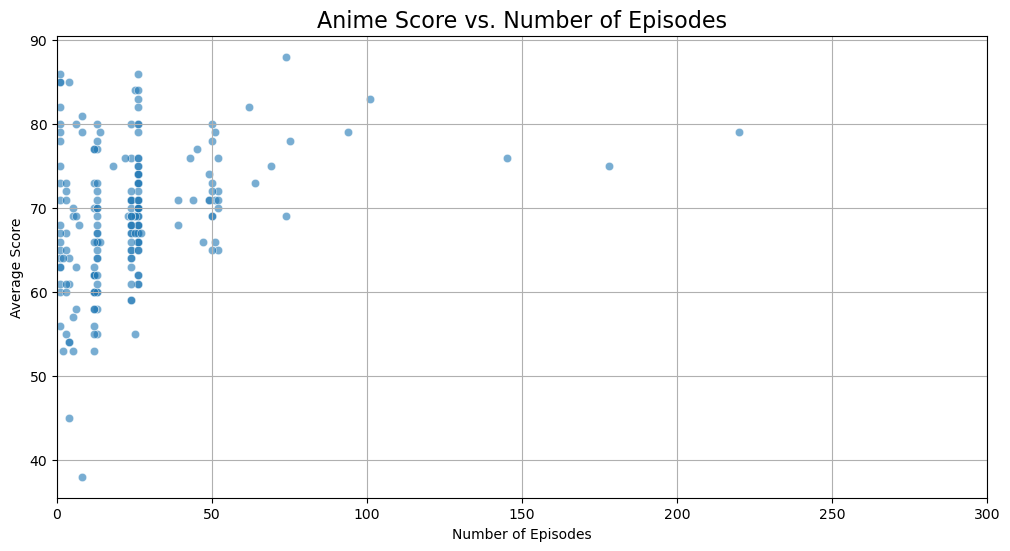

In [4]:
# Relationships Between Episodes and Score

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='episodes', y='score', alpha=0.6)
plt.title('Anime Score vs. Number of Episodes', fontsize=16)
plt.xlabel('Number of Episodes')
plt.ylabel('Average Score')
plt.xlim(0, 300) # Limiting x-axis to see the dense area more clearly
plt.grid(True)
plt.show()

The scatterplot analysis of episode count against score does not reveal a strong linear relationship. Most anime, including highly rated ones such as Monster (score: 88), fall within 100 episodes. While a few long-running series such as Naruto (220 episodes) and One Piece achieve high ratings, these are exceptions rather than the norm.

The number of episodes doesn't seem to be a strong predictor of score. A show is not necessarily better or worse just because it's long or short.

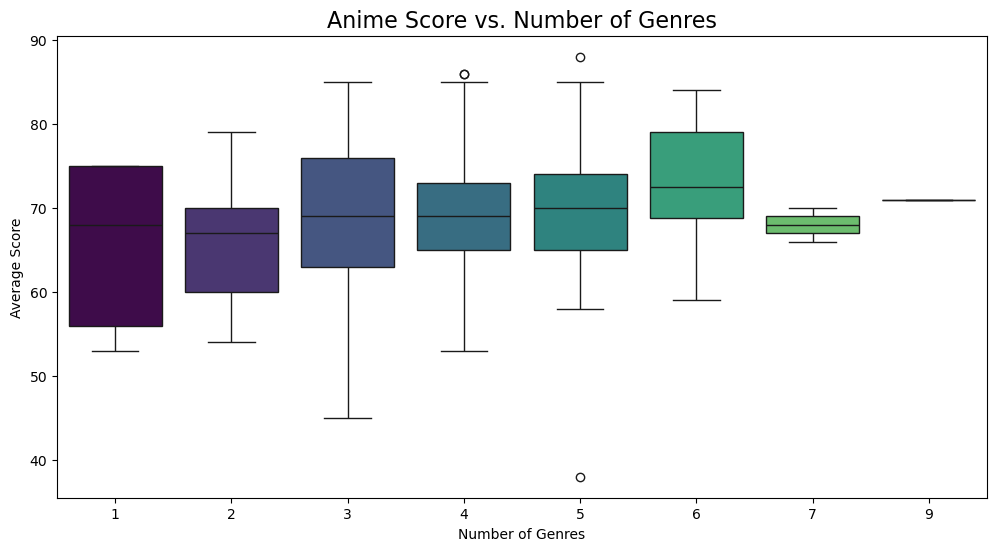

In [6]:
# Relationship Between Genre Count and Score

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='genre_count', y='score', hue='genre_count', palette='viridis', legend=False)
plt.title('Anime Score vs. Number of Genres', fontsize=16)
plt.xlabel('Number of Genres')
plt.ylabel('Average Score')
plt.show()

The boxplot examining the relationship between the number of genres and score shows that anime with 3–5 genres tend to have slightly higher median scores compared to those with very few (1–2) or many (7+) genres. Additionally, anime with extreme genre counts exhibit more variability, indicating inconsistency in quality.

While not a dramatic effect, there's a slight tendency for shows with 3-5 genres to be rated higher. This relationship is more noticeable than the one with episode count. This may suggest that balancing multiple genres allows for richer storytelling without becoming overly complex or unfocused.

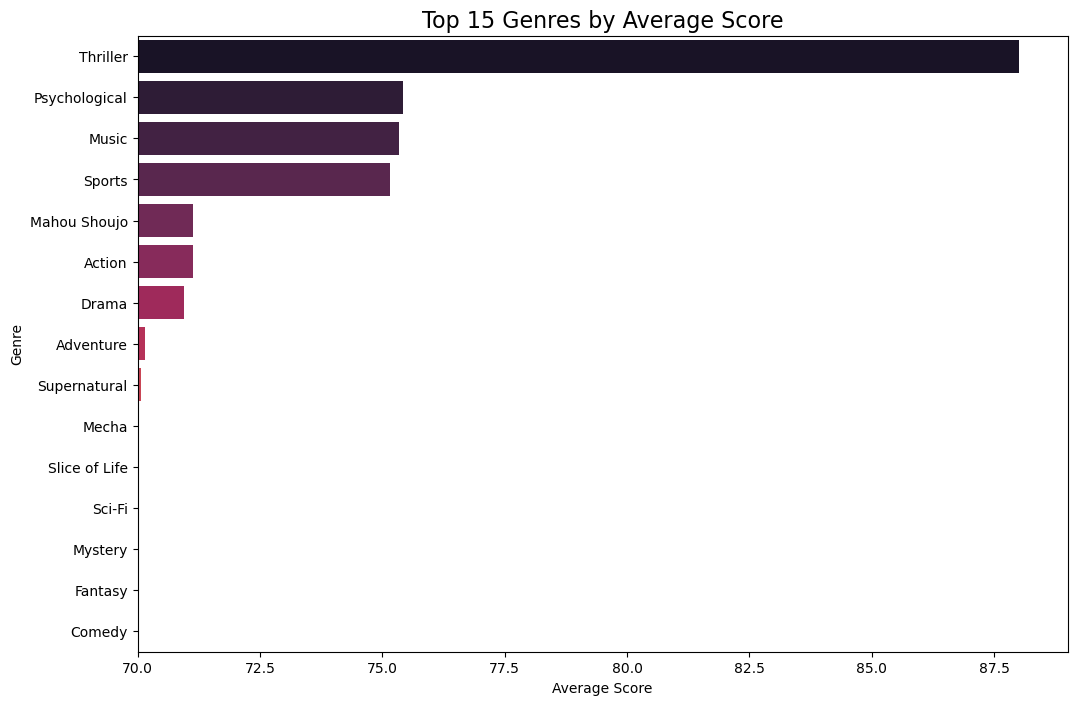

In [8]:
# Relationship Between Individual Genres and Score

df_genres = df.assign(genres=df['genres'].str.split(', ')).explode('genres')

# Calculate the average score for each genre and get the top 15
top_genres = df_genres.groupby('genres')['score'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
# Assign 'y' to 'hue' and disable the legend to match the warning's advice
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='rocket', legend=False)
plt.title('Top 15 Genres by Average Score', fontsize=16)
plt.xlabel('Average Score')
plt.ylabel('Genre')
plt.xlim(70, top_genres.values.max() + 1)
plt.show()

This visualization reveals a very strong relationship. Certain genres are clearly associated with higher scores.

Genres such as Psychological, Thriller, Drama, and Mystery consistently show higher average scores. These categories often involve intricate narratives and mature themes, which may appeal more to dedicated fans and critics. For instance, Monster, which scores highly, belongs to several of these genres.

In contrast, genres such as Mecha and certain subsets of Sci-Fi also rank well, though to a lesser extent. Other genres exhibit lower average ratings, highlighting a strong association between genre type and audience reception.

The specific genre of an anime is the strongest predictor of its score among the features analyzed. Genre clearly influences viewer ratings more than either the number of episodes or the number of genres.

# Conclusion

After exploring the dataset, the single most significant conclusion is that content and theme (represented by genre) are far more indicative of an anime's quality score than its length or complexity (number of genres).

While the number of episodes has almost no discernible impact on score and the count of genres has only a minor influence, the specific genres an anime belongs to show a strong correlation with higher scores. To find a high-quality anime, a viewer would be better off looking for shows in the Drama, Psychological, or Mystery categories rather than simply looking for a show of a particular length.